## Travel Planning Agent

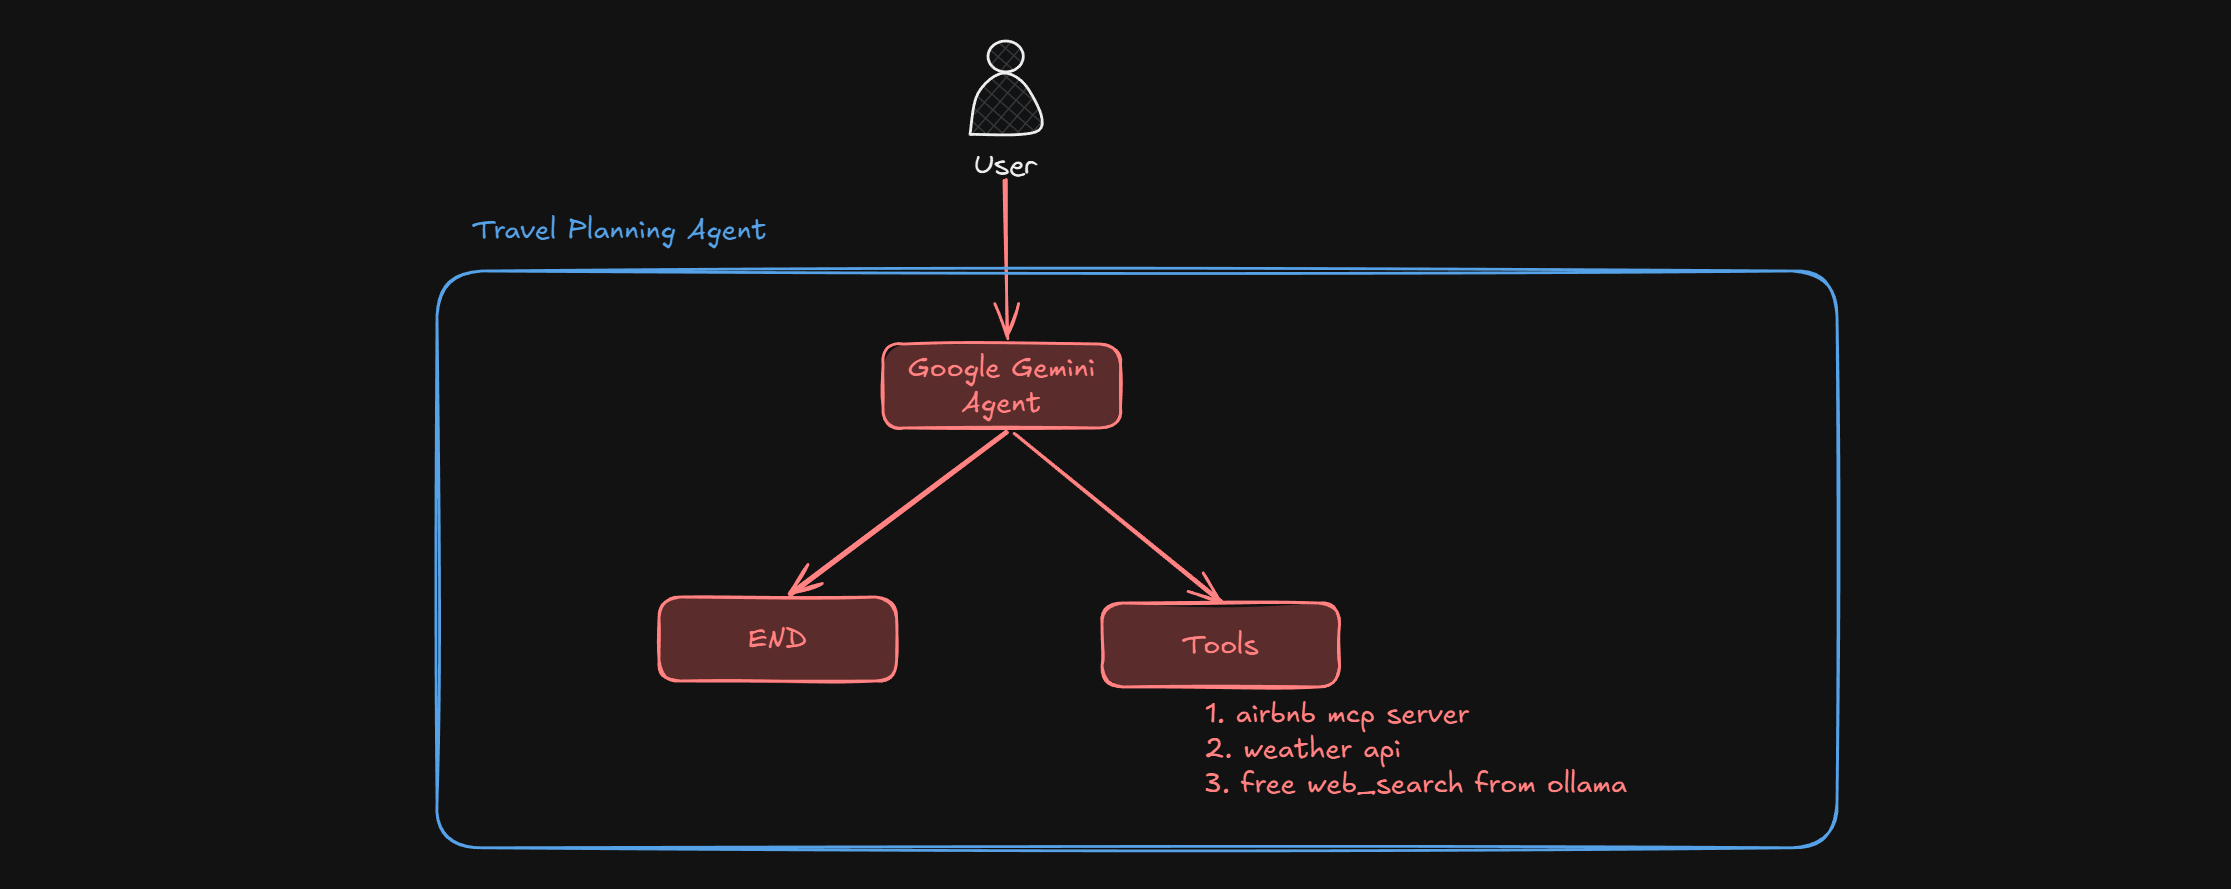

Links
- https://github.com/openbnb-org/mcp-server-airbnb
- https://www.weatherapi.com/my/
- https://ollama.com/settings/keys
- https://aistudio.google.com/api-keys

In [1]:
from dotenv import load_dotenv
load_dotenv()

from langchain_google_genai import ChatGoogleGenerativeAI

from langchain.agents import create_agent
from langchain_core.tools import tool

import ollama 
import json
import requests

In [2]:
@tool
def web_search(query: str) -> str:
    """
    Perform a live web search using Ollama Cloud Web Search API.
    Input: query string
    Output: formatted JSON string
    """
    response = ollama.web_search(query, max_results=2)
    return response.results

response = web_search.invoke({"query": "best travel destinations in Europe"})

c:\Users\laxmi\anaconda3\envs\ml\Lib\site-packages\pydantic\v1\main.py:1054: UserWarning: LangSmith now uses UUID v7 for run and trace identifiers. This warning appears when passing custom IDs. Please use: from langsmith import uuid7
            id = uuid7()
Future versions will require UUID v7.
  input_data = validator(cls_, input_data)


In [3]:
response

[WebSearchResult(content='[Skip to main content](https://www.cntraveler.com/www.cntraveler.com#main-content)\n\nSave this story\n\nSave this story\n\nAs we edge closer to the end of each year, we begin to look ahead to the destinations we’re most looking forward to visiting (and recommending to you, our fellow travelers) for the following 12 months. We’ve asked our expert contributors from all around the globe to nominate the spots that are on the up—the places that are on their radar thanks to a flock of hotel openings, major cultural moments, talk of new flight routes, or concerted conservation efforts taking root. These nominations make up the [Best Places to Go in 2026](https://www.cntraveler.com/story/the-best-places-to-go-in-2026)—the places worthy of your precious annual leave and hard-earned spending money.\n\nFor the second year running, in addition to turning our gaze to global destinations in the [Best Places to Go in the World in 2026](https://www.cntraveler.com/story/the-b

In [4]:
import requests
from langchain_core.tools import tool
import os

@tool
def get_weather(location: str) -> str:
    """Get current weather for a location using WeatherAPI.com.
    
    Use for queries about weather, temperature, or conditions in any city.
    Examples: "weather in Paris", "temperature in Tokyo", "is it raining in London"
    
    Args:
        location: City name (e.g., "New York", "London", "Tokyo")
        
    Returns:
        Current weather information including temperature and conditions.
    """

    url = (
        "http://api.weatherapi.com/v1/current.json"
        f"?key={os.getenv("WEATHER_API_KEY")}&q={location}&aqi=no"
    )

    response = requests.get(url, timeout=10)
    response.raise_for_status()

    data = response.json()
    return data


# Test
response = get_weather.invoke({"location": "Paris"})
print(response)


{'location': {'name': 'Paris', 'region': 'Ile-de-France', 'country': 'France', 'lat': 48.8667, 'lon': 2.3333, 'tz_id': 'Europe/Paris', 'localtime_epoch': 1763972650, 'localtime': '2025-11-24 09:24'}, 'current': {'last_updated_epoch': 1763972100, 'last_updated': '2025-11-24 09:15', 'temp_c': 7.4, 'temp_f': 45.3, 'is_day': 1, 'condition': {'text': 'Partly cloudy', 'icon': '//cdn.weatherapi.com/weather/64x64/day/116.png', 'code': 1003}, 'wind_mph': 9.2, 'wind_kph': 14.8, 'wind_degree': 237, 'wind_dir': 'WSW', 'pressure_mb': 997.0, 'pressure_in': 29.44, 'precip_mm': 0.14, 'precip_in': 0.01, 'humidity': 93, 'cloud': 75, 'feelslike_c': 4.7, 'feelslike_f': 40.5, 'windchill_c': 3.5, 'windchill_f': 38.2, 'heatindex_c': 6.4, 'heatindex_f': 43.5, 'dewpoint_c': 4.9, 'dewpoint_f': 40.9, 'vis_km': 10.0, 'vis_miles': 6.0, 'uv': 0.0, 'gust_mph': 14.0, 'gust_kph': 22.6, 'short_rad': 7.22, 'diff_rad': 3.48, 'dni': 0.0, 'gti': 3.13}}


In [5]:
import subprocess
import sys

@tool
def hotel_search(query):
    """Search for hotels using Airbnb MCP async function."""

    code = f"""
import asyncio
from airbnb_mcp import hotel_search
asyncio.run(hotel_search("{query}"))
"""
    
    result = subprocess.run([sys.executable, '-c', code], capture_output=True, text=True)

    return result.stdout

In [6]:
query = "show me the best hotels in mumbai"
response = hotel_search.invoke({"query": query})

print(response)

Loaded 2 Tools
Tools Available: [StructuredTool(name='airbnb_search', description='Search for Airbnb listings with various filters and pagination. Provide direct links to the user', args_schema={'type': 'object', 'properties': {'location': {'type': 'string', 'description': 'Location to search for (city, state, etc.)'}, 'placeId': {'type': 'string', 'description': 'Google Maps Place ID (overrides the location parameter)'}, 'checkin': {'type': 'string', 'description': 'Check-in date (YYYY-MM-DD)'}, 'checkout': {'type': 'string', 'description': 'Check-out date (YYYY-MM-DD)'}, 'adults': {'type': 'number', 'description': 'Number of adults'}, 'children': {'type': 'number', 'description': 'Number of children'}, 'infants': {'type': 'number', 'description': 'Number of infants'}, 'pets': {'type': 'number', 'description': 'Number of pets'}, 'minPrice': {'type': 'number', 'description': 'Minimum price for the stay'}, 'maxPrice': {'type': 'number', 'description': 'Maximum price for the stay'}, 'cur

### Travel Agent with Google Gemini

In [7]:
# Initialize the LLM
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0.7)

In [8]:
# Combine all tools
tools = [web_search, get_weather, hotel_search]

In [9]:
system_prompt = """You are an expert travel planner with access to:
- web_search(query)
- get_weather(location)
- hotel_search(query)

Goal: Create personalized, realistic itineraries using real-time data.

### Workflow
1. Understand destination, duration (default 5 days), budget, interests, and special needs.
2. Research using multiple web searches (attractions, guides, tips, hidden gems). Check weather.
3. Find accommodations based on budget, area, and proximity.
4. Build day-by-day plan with activities, food, timings, distances, and transport tips.
5. Add weather notes, packing list, budget estimate, local customs, safety, transport options.
6. Present final plan clearly in Markdown: title, duration, daily schedule, hotels, weather, budget, tips, useful links.

### Rules
- Use 3+ web searches.
- Always check weather.
- Provide specific names, places, and timings.
- Keep itinerary realistic and current.
- If duration missing → make a 5-day plan."""

In [12]:
# Create the travel planning agent
travel_agent = create_agent(model=llm, tools=tools, system_prompt=system_prompt)

### Test the Travel Planning Agent

In [13]:
from langchain_core.messages import HumanMessage

# Example query - you can modify this
query = "Plan a 3-day trip to Mumbai for solo traveler"

# Invoke the agent
response = travel_agent.invoke({'messages': [HumanMessage(content=query)]})

In [15]:
# Display the travel plan
response = response['messages'][-1].content[0]['text']

In [16]:
with open("travel_plan.md", "w", encoding="utf-8") as f:
    f.write(response)

In [17]:
# display the response in markdown format
from IPython.display import Markdown, display
display(Markdown(response))

Here is a personalized 3-day itinerary for your solo trip to Mumbai, designed to give you a taste of its vibrant culture, history, and culinary delights.

## 3-Day Solo Traveler's Itinerary: Mumbai Magic

**Duration:** 3 Days
**Traveler:** Solo

### Weather in Mumbai
The current weather in Mumbai is **32.1°C (89.8°F) and overcast**. Mumbai can be quite hot and humid. The best time to visit is typically from October to February for more pleasant temperatures. Be prepared for warm weather and potential humidity during your trip.

### Accommodation Recommendation

For a solo traveler, I recommend looking for accommodation in **Colaba** or **Bandra West**. Colaba is central and close to many major attractions, while Bandra West offers a more relaxed vibe with good dining and nightlife.

*   **Mid-range Hotel (Colaba/Fort area):** Consider searching for boutique hotels or well-reviewed mid-range options in the Colaba or Fort districts. While I couldn't find specific availability through my hotel search, online platforms like Booking.com or Agoda will have options.
*   **Budget-friendly (Hostel in Santacruz):** If you're on a tighter budget and open to hostels, areas like Santacruz offer good options (e.g., Nap Manor Hostels was mentioned in my research). Santacruz is further from South Mumbai but generally safer and close to the airport.

### Day-by-Day Itinerary

#### Day 1: Colonial Charm & Coastal Views (South Mumbai)

*   **Morning (9:00 AM - 1:00 PM): Iconic Landmarks**
    *   Start your day early at the **Gateway of India**, an iconic arch monument. Enjoy the sea breeze and take photos.
    *   Walk across to the magnificent **Taj Mahal Palace Hotel**, an architectural marvel. You can admire its exterior or step into the public areas for a glimpse of its grandeur. Consider a coffee at The Sea Lounge for harbor views.
    *   Visit the **Chhatrapati Shivaji Maharaj Vastu Sangrahalaya (formerly Prince of Wales Museum)**. This museum offers a deep dive into Indian history, art, and culture.
*   **Lunch (1:00 PM - 2:00 PM): Local Flavors in Colaba**
    *   Explore the **Colaba Causeway Market** for souvenirs and vibrant street life. Be ready to haggle!
    *   Grab lunch at **Leopold Cafe**, a historic establishment in Colaba known for its food and lively atmosphere. Try some classic Indian dishes.
*   **Afternoon (2:00 PM - 6:00 PM): Gardens & Cricket**
    *   Take a taxi or auto-rickshaw to **Malabar Hill** to visit the tranquil **Hanging Gardens** and **Kamala Nehru Park**. Enjoy panoramic views of the city and the Arabian Sea.
    *   Alternatively, if you're a cricket fan, visit **Oval Maidan** to witness local cricket matches in action.
*   **Evening (6:00 PM onwards): Sunset at Marine Drive**
    *   Head to **Girgaon Chowpatty Beach** on **Marine Drive** (also known as the "Queen's Necklace"). Enjoy the sunset over the Arabian Sea and soak in the lively atmosphere.
    *   Try some local street food like *bhel puri* or *pav bhaji* from reputable vendors.
    *   **Dinner:** Enjoy dinner at a restaurant along Marine Drive. "Revival restaurant" was mentioned as a good vegetarian option.

#### Day 2: Spiritual Sites & Historic Hubs

*   **Morning (7:00 AM - 12:00 PM): Spiritual Awakening**
    *   Start early with a visit to **Haji Ali Dargah**, a mosque and tomb located on an islet off the coast. Check tide timings as it's only accessible during low tide via a causeway.
    *   Walk to the nearby **Shree Mahalakshmi Temple**, an 18th-century Hindu temple dedicated to the Goddess Mahalakshmi.
*   **Lunch (12:00 PM - 1:00 PM): Near the Terminus**
    *   Take a taxi or Uber to the **Chhatrapati Shivaji Maharaj Terminus (CSMT)**.
    *   Have lunch at one of the many restaurants or street food stalls opposite CSMT. This is also a great spot to observe Mumbai's famous *dabbawalas* (lunchbox deliverymen) in action around lunchtime.
*   **Afternoon (1:00 PM - 6:00 PM): Bandra Exploration**
    *   Take a taxi/Uber to **Bandra West**, a vibrant neighborhood.
    *   Visit the **Basilica of Our Lady of the Mount**, one of Mumbai's oldest churches, offering peaceful ambiance and impressive architecture.
    *   Explore **Bandra Fort (Castella de Aguada)**, a 17th-century Portuguese watchtower, for historical insights and another beautiful sunset view over the Arabian Sea.
*   **Evening (6:00 PM onwards): Bandra Nightlife**
    *   Bandra West is known for its upscale bars and clubs. Enjoy a relaxed evening or experience the local nightlife.
    *   **Dinner:** Explore the diverse culinary scene in Bandra, offering everything from local eateries to international cuisine.

#### Day 3: Ancient Caves & Cultural Immersion

*   **Morning (9:00 AM - 2:00 PM): Elephanta Caves Excursion**
    *   Take a ferry from the Gateway of India to **Elephanta Island** to visit the UNESCO World Heritage Site of **Elephanta Caves**. These ancient rock-cut caves, dating back to the 2nd century BC, house intricate sculptures of Hindu deities, primarily Shiva.
    *   The ferry ride takes about an hour each way. Once on the island, you can take a toy train and then climb about 120 steps to reach the caves.
    *   **Lunch:** There are restaurants on Elephanta Island where you can grab a meal before heading back.
*   **Afternoon (2:00 PM - 5:00 PM): Dharavi Slum Tour (Optional)**
    *   Upon returning to the Gateway of India, consider an ethically guided **Dharavi slum tour**. This offers a unique perspective on the community, small-scale industries, and daily life in one of Asia's largest slums. Ensure you choose a reputable tour operator that contributes back to the community.
*   **Evening (5:00 PM onwards): Farewell Mumbai**
    *   Depending on your flight schedule, you can revisit a favorite spot, do some last-minute souvenir shopping, or enjoy a relaxing dinner.
    *   **Dinner:** Indulge in a final Mumbai meal, perhaps trying some of the street food you missed or a restaurant with a cuisine you enjoyed most.

### Transportation Tips

*   **Ride-hailing Apps:** For convenience and safety, use **Uber** or **Ola cabs**. They are widely available, affordable, and offer tracking.
*   **Auto-rickshaws:** Good for shorter distances in suburban areas, but not allowed in South Mumbai. Always insist on the meter.
*   **Walking:** Many attractions in South Mumbai are walkable, especially in areas like Colaba and Fort.
*   **Avoid Local Trains/Buses:** For first-time solo travelers, especially during peak hours, local trains and buses can be extremely crowded and overwhelming. It's generally recommended to avoid them for comfort and safety.

### Budget Estimate (per day, excluding accommodation)

*   **Food:** ₹800 - ₹1500 (USD 10-20) - can be lower if you stick to street food, higher for mid-range restaurants.
*   **Transportation:** ₹300 - ₹700 (USD 4-9) - using Uber/Ola, auto-rickshaws.
*   **Activities/Entrance Fees:** ₹500 - ₹1000 (USD 6-13) - depending on the attractions.
*   **Miscellaneous (souvenirs, drinks):** ₹500+ (USD 6+)
*   **Total Estimated Daily Spend:** ₹2100 - ₹3200 (USD 27-42)

### Packing List

*   **Lightweight, breathable clothing:** Cotton and linen are ideal due to the warm and humid weather.
*   **Modest attire:** To respect local customs, particularly when visiting religious sites, consider covering your shoulders and knees.
*   **Comfortable walking shoes/sandals:** You'll be doing a lot of walking.
*   **Sun protection:** Hat, sunglasses, and high SPF sunscreen.
*   **Reusable water bottle:** Stay hydrated, but only drink bottled or filtered water.
*   **Small backpack/day bag:** For essentials.
*   **Portable charger:** For your phone.
*   **Basic first-aid kit:** Including any personal medications, stomach remedies, and hand sanitizer.
*   **Mask:** For dusty or crowded areas.

### Local Customs & Safety Tips

*   **Dress Modestly:** Especially when visiting religious sites.
*   **Stay Hydrated:** Drink plenty of bottled water. Avoid tap water and ice unless sure of its source.
*   **Food Safety:** While street food is delicious, choose popular stalls with high turnover. If unsure, opt for well-established restaurants.
*   **Bargaining:** It's common in markets, so be prepared to haggle politely.
*   **Be Aware of Surroundings:** Like any large city, be mindful of your belongings and avoid flashing valuables.
*   **Photography:** Always ask for permission before taking photos of people.
*   **"Namaste":** A respectful greeting that can go a long way.
*   **Night Safety:** Exercise caution when out alone at night. Stick to well-lit, populated areas, and use ride-hailing services.
*   **Scams:** Be wary of overly friendly strangers offering unsolicited help or tours.

### Useful Links

*   **m-indicator app:** For local train and bus schedules (though not recommended for first-time solo travelers, it can be useful for general awareness).
*   **Uber/Ola apps:** For reliable transportation.
*   **Google Maps:** For navigation.

Enjoy your incredible solo adventure in Mumbai!